<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/An%C3%A1lise_de_sentimentos_em_textos_financeiros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import spacy
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re

<Axes: xlabel='Sentiment', ylabel='count'>

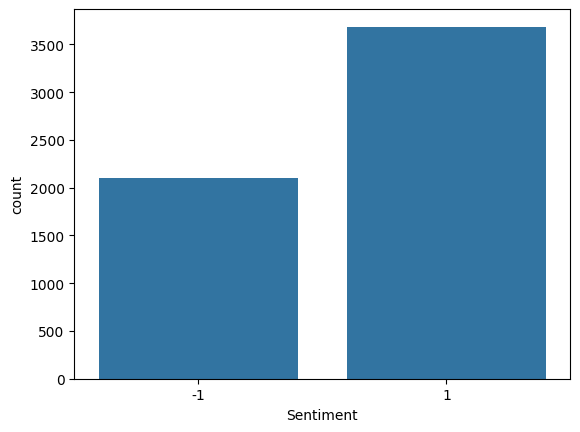

In [2]:
df = pd.read_csv("/content/stock_data.csv")
sns.countplot(x = df["Sentiment"])

In [3]:
df.isnull().sum()

,0
Text,0
Sentiment,0


In [4]:
pln = spacy.load("en_core_web_sm")
stop_words = spacy.lang.en.stop_words.STOP_WORDS

In [5]:
def preprocessing(text):
  # Deixando texto todo em lowercase
  text = text.lower()

  # Retirando @ de usuario
  text = re.sub(r"@[A-Za-z0-9$-_@.&+]+", " ", text)
  # Retirando links
  text = re.sub(r"https?://[A-Za-z0-9./_]+", " ", text)
  # Retirando espaços em branco
  text = re.sub(r" +", " ", text)

  doc = pln(text)
  lista = []
  for token in doc:
    lista.append(token.lemma_)

  lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in string.punctuation]
  lista = " ".join([str(elemento) for elemento in lista if not elemento.isdigit()])
  return lista

In [7]:
df["Text"] = df["Text"].apply(preprocessing)
df.head(10)

,Text,Sentiment
0,kicker watchlist xide tit soq pnk cpw bpz aj t...,1
1,user aap movie return fea geed indicator trade...,1
2,user I afraid short amzn look like near monopo...,1
3,mnta 12.00,1
4,oi 21.37,1
5,pgnx 3.04,1
6,aap user current downtrend break short term co...,-1
7,monday relative weakness nyx win tie tap ice i...,-1
8,goog ower trend line channel test volume support,1
9,aap watch tomorrow ong entry,1


In [8]:
positive = df[df["Sentiment"] == 1]
negative = df[df["Sentiment"] == -1]

In [9]:
text_positive = positive["Text"].tolist()
text_negative = negative["Text"].tolist()

len(text_positive), len(text_negative)

(3685, 2106)

In [10]:
text_positive_string = " ".join(text_positive)
text_negative_string = " ".join(text_negative)

In [ ]:
doc_positive = pln(text_positive_string)
from spacy import displacy
displacy.render(doc_positive, style = "ent", jupyter = True)

In [ ]:
enterprise_positive = []
for entidade in doc_positive.ents:
  if entidade.label_ == "ORG":
    enterprise_positive.append(entidade.text)

In [17]:
doc_negative = pln(text_negative_string)
enterprise_negative = []
for entidade in doc_negative.ents:
  if entidade.label_ == "ORG":
    enterprise_negative.append(entidade.text)

In [31]:
# empresas_positivas_negativas: empresas que as pessoas estão falando bem e também estão falando mal
enterprise_mixed = list(
    element for element in enterprise_negative if element in enterprise_positive
)
len(enterprise_mixed)

52

In [42]:
# empresas_somente_positivas: empresas que as pessoas estão falando bem
enterprise_solo_positve = list(
    element for element in enterprise_positive if element not in enterprise_negative
)
print(enterprise_solo_positve)

['agnx tv', 'isi', 'vng huge news patent', 'nhod', 'nhod', 'vng', 'vng mil', 'vng', 'zcs', 'vng post nice', 'mca', 'vng', 'kreme doughnuts inc ic xchange', 'financial continue rip easy money', 'massachusetts state automobile dealer association', 'eni', 'amzn data', 'cva', 'ford', 'sxc break', "cy'14 revenue upside estimate", 'kog', 'amwd coil', 'p&f', 'mt beav', 'samsung', 'aon', 'wells fargo wfc deliver moon', 'nkd sina breakout stock', 'kos nkd mov ntsp', 'ssys v nkd storm week 4.29', 'un', 'la sesi?n', 'alcista de final de sesi?n', 'bastard amzn', 'abc', 'spx spy sfy', 'zcs', '501,60 chance', 'nvt', 'nvt', 'bank america', 'intel', 'to12', 'csn sa', 'dnkn lot', 'ltra base', 'kos nkd mov ntsp', 'ssys v invn report', 'bank america', 'nat', 'gdi', 'bank america good bank', 'steve job medical', 'gmc miss party', 'kbh break', 'vision csx', 'snss', 'nfx swy safeway inc bullishness march', 'gtat', 'microsoft ebay rip near pt', 'jefferie price target', 'nfx moon easy long trade', 'vng', 'nkd

In [45]:
# empresas_somente_negativas: empresas que as pessoas estão falando mal
enterprise_solo_negative = list(
    element for element in enterprise_negative if element not in enterprise_positive
)
print(enterprise_solo_negative)

['nyx', 'int bmc aon', 'american international', 'sony', 'es_f', 'kutcher star', 'gmc nfx slam', 'zagg', 'amzn time bird', 'spx spy stock fin', 'clearwire corp arge trade bearish', 'shot ceco', 'hban green', 'spx green weekly', 'mgm catch', 'mcp crater management', 'spx spy m', 'de 14.75', 'wks de outside', 'point&figure', 'h s', 'to10', 'ssys nov', 'nissan', 'netflix bull', 'eade stock lag es_f', 'bull', 'automotive inc option', 'ft71', 'channel bull', 'vmw', 'si vfc cae', 'bull user h break', 'cboe', 'nkd eade', 'mov', 'hsbc', 'olle dice', 'nhi', 'nfx netflix inc nfx increase', 'al v dell inc case', 'user aap rookie', 'short//', 'also)//', 'spy s', 'mco spx spy s&p', 'mco spx spy cnbc', 'hsbc', 'prudential', 'h&s', 'un sa', 'wal mart', 'ma13', 'deutsche bank', 'wal mart', 'barron blog verifone', 'wal mart de mexico 4q', 'deutsche bank', 'faz', 'bloomberg tv', 'nsph today', 'mon w/', '50ma ed', 'nflx drop news apo', 'apo mcp', 'gm slam', 'fbi', 'dia qqq', 'dia qqq break', 'gpn mason',